<a href="https://colab.research.google.com/github/villabon89-commits/Proyecto-RappiPlus-de-datos-a-decisiones-de-negocio/blob/main/S12_Estudiante_Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [ ]:
import pandas as pd

In [ ]:
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [ ]:
print('Orders DataFrame:')
display(orders.head())

print('\nCatalog DataFrame:')
display(catalog.head())

print('\nMarketing DataFrame:')
display(marketing.head())

Orders DataFrame:


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28



Catalog DataFrame:


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"



Marketing DataFrame:


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


In [ ]:
# Limpieza del DataFrame orders

# 1. Eliminar filas con NaN en columnas críticas para el cálculo de monto_total
orders.dropna(subset=['cantidad', 'precio_unitario', 'monto_descuento'], inplace=True)

# 2. Eliminar filas con cantidad no positiva, que resultan en montos_total negativos
# Es importante hacer esto después de manejar los NaNs en cantidad
orders = orders[orders['cantidad'] > 0]

# 3. Recalcular y actualizar 'monto_total' para asegurar consistencia
orders['monto_total'] = (orders['cantidad'] * orders['precio_unitario'] - orders['monto_descuento']).round(2)

# 4. Estandarizar la columna 'pais' a 'Title Case'
orders['pais'] = orders['pais'].astype(str).str.title()

# 5. Llenar NaNs en otras columnas categóricas con 'Desconocido'
categorical_cols_with_nan = ['dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto']
for col in categorical_cols_with_nan:
    if col in orders.columns:
        orders[col].fillna('Desconocido', inplace=True)

# The 'calculated_monto_total' column is created in a later step (cell de2705a1)
# Removing the drop operation here to prevent KeyError if it doesn't exist yet.
# orders.drop(columns=['calculated_monto_total'], inplace=True)

print('\n--- Orders DataFrame después de la limpieza ---')
print(orders.info())
print('\nDescriptive statistics for numerical columns after cleaning:')
print(orders.describe())
print('\nUnique values for cleaned categorical columns (top 5):')
for col in orders.select_dtypes(include='object').columns:
    print(f'- {col}: {orders[col].value_counts().head()}')


--- Orders DataFrame después de la limpieza ---
<class 'pandas.core.frame.DataFrame'>
Index: 25046 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25046 non-null  object 
 1   id_usuario          25046 non-null  object 
 2   fecha_hora_pedido   25046 non-null  object 
 3   pais                25046 non-null  object 
 4   dispositivo         25046 non-null  object 
 5   fuente_referencia   25046 non-null  object 
 6   nombre_producto     25046 non-null  object 
 7   categoria_producto  25046 non-null  object 
 8   cantidad            25046 non-null  float64
 9   precio_unitario     25046 non-null  float64
 10  monto_descuento     25046 non-null  float64
 11  monto_total         25046 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.5+ MB
None

Descriptive statistics for numerical columns after cleaning:
           cantidad  precio_unitario  mont

/tmp/ipykernel_44428/1581238266.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders[col].fillna('Desconocido', inplace=True)


In [ ]:
# Limpieza del DataFrame marketing

# 1. Llenar NaNs en la columna 'canal' con 'Desconocido'
marketing['canal'].fillna('Desconocido', inplace=True)

print('\n--- Marketing DataFrame después de la limpieza ---')
print(marketing.info())
print('\nUnique values for cleaned categorical columns (top 5):')
for col in marketing.select_dtypes(include='object').columns:
    print(f'- {col}: {marketing[col].value_counts().head()}')


--- Marketing DataFrame después de la limpieza ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1620 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB
None

Unique values for cleaned categorical columns (top 5):
- fecha: fecha
2025-01-01    9
2025-01-02    9
2025-01-03    9
2025-01-04    9
2025-01-05    9
Name: count, dtype: int64
- pais: pais
Mexico       540
Colombia     540
Argentina    540
Name: count, dtype: int64
- id_campaña: id_campaña
organic_Mexico          180
paid_search_Mexico      180
social_Mexico           180
organic_Colombia        180
paid_search_Colombia    180
Name: count, dtype: int64
- canal: canal
paid_search    507
organ

/tmp/ipykernel_44428/2667457499.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  marketing['canal'].fillna('Desconocido', inplace=True)


In [ ]:
print('\n--- Verificación de Calidad de Datos del DataFrame Orders ---')

# 1. Convertir 'fecha_hora_pedido' a datetime
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'])
print('\nTipos de datos después de la conversión:')
print(orders.info())

# 2. Buscar y eliminar duplicados
initial_rows = orders.shape[0]
orders.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - orders.shape[0]
print(f'\nNúmero de filas duplicadas eliminadas: {duplicates_removed}')

# 3. Revisar variables numéricas en busca de valores inválidos (ej. no positivos)
print('\nEstadísticas descriptivas para columnas numéricas:')
print(orders.describe())

# Verificar valores no positivos en 'cantidad' y 'precio_unitario'
non_positive_quantity = orders[orders['cantidad'] <= 0]
non_positive_price = orders[orders['precio_unitario'] <= 0]
print(f'\nPedidos con cantidad no positiva: {non_positive_quantity.shape[0]}')
print(f'Pedidos con precio no positivo: {non_positive_price.shape[0]}')

# 4. Verificar la consistencia de 'monto_total'
# Calcular el total esperado basándose en cantidad, precio unitario y descuento
orders['calculated_monto_total'] = orders['cantidad'] * orders['precio_unitario'] - orders['monto_descuento']

mismatch_totals = orders[orders['monto_total'].round(2) != orders['calculated_monto_total'].round(2)]
print(f'\nPedidos donde monto_total no coincide con el total calculado: {mismatch_totals.shape[0]}')

# Por simplicidad, si hay discrepancias, podemos optar por recalcular o marcar.
# Para este ejercicio, asumiremos que el total calculado es correcto y actualizaremos 'monto_total' si hay discrepancias.
# O, simplemente podemos eliminar la columna 'calculated_monto_total' si el 'monto_total' original se considera fiable.
# Por ahora, solo los reportaré. Si es necesario, podemos decidir cómo manejarlos (ej. actualizar `monto_total` o eliminar filas).

# 5. Revisar variables categóricas
print('\nValores únicos para columnas categóricas (top 5):')
for col in orders.select_dtypes(include='object').columns:
    print(f'- {col}: {orders[col].value_counts().head()}')


--- Verificación de Calidad de Datos del DataFrame Orders ---

Tipos de datos después de la conversión:
<class 'pandas.core.frame.DataFrame'>
Index: 25046 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25046 non-null  object        
 1   id_usuario          25046 non-null  object        
 2   fecha_hora_pedido   25046 non-null  datetime64[ns]
 3   pais                25046 non-null  object        
 4   dispositivo         25046 non-null  object        
 5   fuente_referencia   25046 non-null  object        
 6   nombre_producto     25046 non-null  object        
 7   categoria_producto  25046 non-null  object        
 8   cantidad            25046 non-null  float64       
 9   precio_unitario     25046 non-null  float64       
 10  monto_descuento     25046 non-null  float64       
 11  monto_total         25046 non-null  float64       
dtypes:

In [ ]:
print('\n--- Verificación de Calidad de Datos del DataFrame Catalog ---')

# 1. Buscar y eliminar duplicados
initial_rows_catalog = catalog.shape[0]
catalog.drop_duplicates(inplace=True)
duplicates_removed_catalog = initial_rows_catalog - catalog.shape[0]
print(f'\nNúmero de filas duplicadas eliminadas del catálogo: {duplicates_removed_catalog}')

# 2. Revisar variables numéricas en busca de valores inválidos (ej. no positivos)
print('\nEstadísticas descriptivas para columnas numéricas en el catálogo:')
print(catalog.describe())

# Verificar valores no positivos en 'costo_unitario'
non_positive_costo = catalog[catalog['costo_unitario'] <= 0]
print(f'\nElementos del catálogo con costo_unitario no positivo: {non_positive_costo.shape[0]}')

# 3. Revisar variables categóricas
print('\nValores únicos para columnas categóricas en el catálogo (top 5):')
for col in catalog.select_dtypes(include='object').columns:
    print(f'- {col}: {catalog[col].value_counts().head()}')


--- Verificación de Calidad de Datos del DataFrame Catalog ---

Número de filas duplicadas eliminadas del catálogo: 0

Estadísticas descriptivas para columnas numéricas en el catálogo:
       costo_unitario
count        7.000000
mean       102.252857
std        111.011563
min         10.120000
25%         16.905000
50%         25.210000
75%        182.975000
max        280.680000

Elementos del catálogo con costo_unitario no positivo: 0

Valores únicos para columnas categóricas en el catálogo (top 5):
- nombre_producto: nombre_producto
Laptop-Gaming-16GB      1
Phone-Pro-128GB         1
Tablet-Standard-64GB    1
Blender-XL-Red          1
Vacuum-Pro-Black        1
Name: count, dtype: int64
- categoria_producto: categoria_producto
Electrónica    3
Hogar          2
Moda           2
Name: count, dtype: int64
- proveedor: proveedor
Fuller, Pena and Myers     1
King Ltd                   1
Bowers LLC                 1
Long-Reid                  1
Rivera, Carr and Finley    1
Name: count, dt

In [ ]:
print('\n--- Verificación de Calidad de Datos del DataFrame Marketing ---')

# 1. Convertir 'fecha' a datetime
marketing['fecha'] = pd.to_datetime(marketing['fecha'])
print('\nTipos de datos después de la conversión para marketing:')
print(marketing.info())

# 2. Buscar y eliminar duplicados
initial_rows_marketing = marketing.shape[0]
marketing.drop_duplicates(inplace=True)
duplicates_removed_marketing = initial_rows_marketing - marketing.shape[0]
print(f'\nNúmero de filas duplicadas eliminadas de marketing: {duplicates_removed_marketing}')

# 3. Revisar variables numéricas en busca de valores inválidos (ej. no positivos)
print('\nEstadísticas descriptivas para columnas numéricas en marketing:')
print(marketing.describe())

# Verificar valores no positivos en 'gasto'
non_positive_gasto = marketing[marketing['gasto'] <= 0]
print(f'\nEntradas de marketing con gasto no positivo: {non_positive_gasto.shape[0]}')

# 4. Revisar variables categóricas
print('\nValores únicos para columnas categóricas en marketing (top 5):')
for col in marketing.select_dtypes(include='object').columns:
    print(f'- {col}: {marketing[col].value_counts().head()}')


--- Verificación de Calidad de Datos del DataFrame Marketing ---

Tipos de datos después de la conversión para marketing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB
None

Número de filas duplicadas eliminadas de marketing: 0

Estadísticas descriptivas para columnas numéricas en marketing:
                     fecha       gasto
count                 1620  1620.00000
mean   2025-03-31 12:00:00  1772.74292
min    2025-01-01 00:00:00   501.11000
25%    2025-02-14 18:00:00  1128.03000
50%    2025-03-31 12:00:00  1782.42500
75% 

In [ ]:
# Exportar datasets limpios
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)
print('\nLos DataFrames limpios han sido exportados a orders_clean.csv, catalog_clean.csv y marketing_clean.csv')


Los DataFrames limpios han sido exportados a orders_clean.csv, catalog_clean.csv y marketing_clean.csv


In [ ]:
# Para calcular el costo total, necesitamos unir orders con catalog
orders_with_cost = pd.merge(orders, catalog[['nombre_producto', 'costo_unitario']], on='nombre_producto', how='left')

# Calculamos el costo total por línea de pedido
# Asumimos que los productos sin costo en el catálogo tienen costo 0 para este cálculo
orders_with_cost['costo_total_item'] = orders_with_cost['cantidad'] * orders_with_cost['costo_unitario'].fillna(0)

# Parte 1: Rentabilidad del negocio

# 1. Ingreso total (revenue)
revenue_total = orders_with_cost['monto_total'].sum()

# 2. Costo total de productos vendidos
costo_productos_total = orders_with_cost['costo_total_item'].sum()

# 3. Inversión total en marketing
inversion_marketing_total = marketing['gasto'].sum()

# 4. Profit
profit_total = revenue_total - costo_productos_total - inversion_marketing_total

print(f'Ingreso Total (Revenue): {revenue_total:,.2f}')
print(f'Costo Total de Productos Vendidos: {costo_productos_total:,.2f}')
print(f'Inversión Total en Marketing: {inversion_marketing_total:,.2f}')
print(f'Profit Total: {profit_total:,.2f}')

# Parte 2: Comportamiento de ventas

# 1. Ticket promedio por orden
ticket_promedio_por_orden = orders_with_cost.groupby('id_pedido')['monto_total'].sum().mean()

# 2. Cantidad promedio de productos por orden
cantidad_promedio_por_orden = orders_with_cost.groupby('id_pedido')['cantidad'].sum().mean()

# 3. Producto más vendido (por cantidad)
producto_mas_vendido = orders_with_cost.groupby('nombre_producto')['cantidad'].sum().idxmax()
cantidad_producto_mas_vendido = orders_with_cost.groupby('nombre_producto')['cantidad'].sum().max()

# 4. Gasto en marketing por canal
gasto_por_canal = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False)

print(f'\nTicket Promedio por Orden: {ticket_promedio_por_orden:,.2f}')
print(f'Cantidad Promedio de Productos por Orden: {cantidad_promedio_por_orden:,.2f}')
print(f'Producto Más Vendido: {producto_mas_vendido} ({cantidad_producto_mas_vendido:,.0f} unidades)')
print('\nGasto en Marketing por Canal:')
print(gasto_por_canal.apply(lambda x: f'{x:,.2f}'))

Ingreso Total (Revenue): 51,966,982.37
Costo Total de Productos Vendidos: 43,124,069.01
Inversión Total en Marketing: 2,871,843.53
Profit Total: 5,971,069.83

Ticket Promedio por Orden: 2,083.18
Cantidad Promedio de Productos por Orden: 7.12
Producto Más Vendido: Laptop-Gaming-16GB (144,198 unidades)

Gasto en Marketing por Canal:
canal
social         918,043.21
organic        913,533.01
paid_search    863,088.21
Desconocido    177,179.10
Name: gasto, dtype: object


In [ ]:
experiment_df = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
print('Primeras 5 filas del DataFrame de experimento:')
display(experiment_df.head())

Primeras 5 filas del DataFrame de experimento:


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [ ]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS total_usuarios
FROM
    events
GROUP BY
    nombre_evento
ORDER BY
    CASE nombre_evento
        WHEN 'first_visit' THEN 1
        WHEN 'add_to_cart' THEN 2
        WHEN 'add_payment_info' THEN 3
        WHEN 'purchase' THEN 4
        ELSE 5
    END;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,total_usuarios
0,first_visit,7796
1,add_to_cart,7634
2,add_payment_info,6250
3,purchase,6240
4,begin_checkout,7208
5,select_item,7582


In [ ]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH user_counts AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS total_usuarios
    FROM
        events
    GROUP BY
        nombre_evento
),
funnel_ordered AS (
    SELECT
        nombre_evento,
        total_usuarios,
        CASE nombre_evento
            WHEN 'first_visit' THEN 1
            WHEN 'select_item' THEN 2
            WHEN 'add_to_cart' THEN 3
            WHEN 'begin_checkout' THEN 4
            WHEN 'add_payment_info' THEN 5
            WHEN 'purchase' THEN 6
            ELSE 99
        END AS step_order
    FROM
        user_counts
)
SELECT
    f1.nombre_evento AS paso_del_embudo,
    f1.total_usuarios AS usuarios_en_paso,
    LAG(f1.total_usuarios, 1, 0) OVER (ORDER BY f1.step_order) AS usuarios_en_paso_anterior,
    CASE
        WHEN LAG(f1.total_usuarios, 1, 0) OVER (ORDER BY f1.step_order) > 0
        THEN (CAST(f1.total_usuarios AS DECIMAL) * 100.0 / LAG(f1.total_usuarios, 1, 0) OVER (ORDER BY f1.step_order))
        ELSE NULL
    END AS tasa_conversion_paso_a_paso,
    (CAST(f1.total_usuarios AS DECIMAL) * 100.0 / (SELECT total_usuarios FROM funnel_ordered WHERE nombre_evento = 'first_visit')) AS tasa_conversion_desde_first_visit
FROM
    funnel_ordered f1
WHERE f1.nombre_evento IN ('first_visit', 'select_item', 'add_to_cart', 'begin_checkout', 'add_payment_info', 'purchase')
ORDER BY
    f1.step_order;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,paso_del_embudo,usuarios_en_paso,usuarios_en_paso_anterior,tasa_conversion_paso_a_paso,tasa_conversion_desde_first_visit
0,first_visit,7796,0,NaN,100.000000
1,select_item,7582,7796,97.255003,97.255003
2,add_to_cart,7634,7582,100.685835,97.922011
3,begin_checkout,7208,7634,94.419701,92.457671
4,add_payment_info,6250,7208,86.709212,80.169318
5,purchase,6240,6250,99.840000,80.041047


In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [ ]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [ ]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohorts AS (
    SELECT
        id_usuario,
        CAST(fecha_registro AS DATE) AS fecha_registro,
        EXTRACT(YEAR FROM CAST(fecha_registro AS DATE)) AS ano_registro,
        EXTRACT(MONTH FROM CAST(fecha_registro AS DATE)) AS mes_registro
    FROM
        users
),
activity_with_cohort AS (
    SELECT
        ua.id_usuario,
        c.fecha_registro,
        c.ano_registro,
        c.mes_registro,
        ua.dias_despues_registro,
        ua.activo
    FROM
        user_activity AS ua
    JOIN
        cohorts AS c ON ua.id_usuario = c.id_usuario
)
SELECT
    ano_registro,
    mes_registro,
    COUNT(DISTINCT id_usuario) AS usuarios_registrados,
    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 0 AND dias_despues_registro < 7 AND activo = 1 THEN id_usuario ELSE NULL END) AS retenido_w1,
    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 7 AND dias_despues_registro < 14 AND activo = 1 THEN id_usuario ELSE NULL END) AS retenido_w2,
    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 14 AND dias_despues_registro < 21 AND activo = 1 THEN id_usuario ELSE NULL END) AS retenido_w3,
    CAST(COUNT(DISTINCT CASE WHEN dias_despues_registro >= 0 AND dias_despues_registro < 7 AND activo = 1 THEN id_usuario ELSE NULL END) AS DECIMAL) * 100 / COUNT(DISTINCT id_usuario) AS semana_1,
    CAST(COUNT(DISTINCT CASE WHEN dias_despues_registro >= 7 AND dias_despues_registro < 14 AND activo = 1 THEN id_usuario ELSE NULL END) AS DECIMAL) * 100 / COUNT(DISTINCT id_usuario) AS semana_2,
    CAST(COUNT(DISTINCT CASE WHEN dias_despues_registro >= 14 AND dias_despues_registro < 21 AND activo = 1 THEN id_usuario ELSE NULL END) AS DECIMAL) * 100 / COUNT(DISTINCT id_usuario) AS semana_3
FROM
    activity_with_cohort
GROUP BY
    ano_registro,
    mes_registro
ORDER BY
    ano_registro,
    mes_registro;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,ano_registro,mes_registro,usuarios_registrados,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025.0,1.0,1627,0,697,668,0.0,42.839582,41.057160
1,2025.0,2.0,1444,0,611,609,0.0,42.313019,42.174515
2,2025.0,3.0,1636,0,677,705,0.0,41.381418,43.092910
3,2025.0,4.0,1606,0,680,697,0.0,42.341220,43.399751
4,2025.0,5.0,1687,0,695,676,0.0,41.197392,40.071132


In [ ]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# Separar los datos por variante
control_group = experiment_df[experiment_df['variante'] == 'control']
tratamiento_group = experiment_df[experiment_df['variante'] == 'tratamiento']

# Calcular el número de conversiones y el total de usuarios para cada grupo
conversions_control = control_group['convirtio'].sum()
nobs_control = len(control_group)

conversions_tratamiento = tratamiento_group['convirtio'].sum()
nobs_tratamiento = len(tratamiento_group)

# Mostrar los datos resumidos
print(f'Grupo de Control: Conversiones = {conversions_control}, Observaciones = {nobs_control}')
print(f'Grupo de Tratamiento: Conversiones = {conversions_tratamiento}, Observaciones = {nobs_tratamiento}')

# Realizar el Z-test para dos proporciones
count = np.array([conversions_control, conversions_tratamiento])
nobs = np.array([nobs_control, nobs_tratamiento])

z_statistic, p_value = proportions_ztest(count, nobs, alternative='two-sided')

print(f'\nEstadístico Z: {z_statistic:.4f}')
print(f'Valor p: {p_value:.4f}')

# Interpretación de los resultados
alpha = 0.05
print(f'\nNivel de significancia (alpha): {alpha}')

if p_value < alpha:
    print('El valor p es menor que alpha. Rechazamos la hipótesis nula.')
    print('Existe una diferencia estadísticamente significativa en la tasa de conversión entre el control y el tratamiento.')
    if (conversions_tratamiento / nobs_tratamiento) > (conversions_control / nobs_control):
        print('La variante de tratamiento tuvo una tasa de conversión MÁS ALTA.')
    else:
        print('La variante de tratamiento tuvo una tasa de conversión MÁS BAJA.')
else:
    print('El valor p es mayor que alpha. No podemos rechazar la hipótesis nula.')
    print('No existe una diferencia estadísticamente significativa en la tasa de conversión entre el control y el tratamiento.')

# Calcular y mostrar las tasas de conversión
conversion_rate_control = conversions_control / nobs_control
conversion_rate_tratamiento = conversions_tratamiento / nobs_tratamiento

print(f'\nTasa de Conversión del Grupo de Control: {conversion_rate_control:.4f}')
print(f'Tasa de Conversión del Grupo de Tratamiento: {conversion_rate_tratamiento:.4f}')

Grupo de Control: Conversiones = 779, Observaciones = 4965
Grupo de Tratamiento: Conversiones = 820, Observaciones = 5035

Estadístico Z: -0.8133
Valor p: 0.4161

Nivel de significancia (alpha): 0.05
El valor p es mayor que alpha. No podemos rechazar la hipótesis nula.
No existe una diferencia estadísticamente significativa en la tasa de conversión entre el control y el tratamiento.

Tasa de Conversión del Grupo de Control: 0.1569
Tasa de Conversión del Grupo de Tratamiento: 0.1629


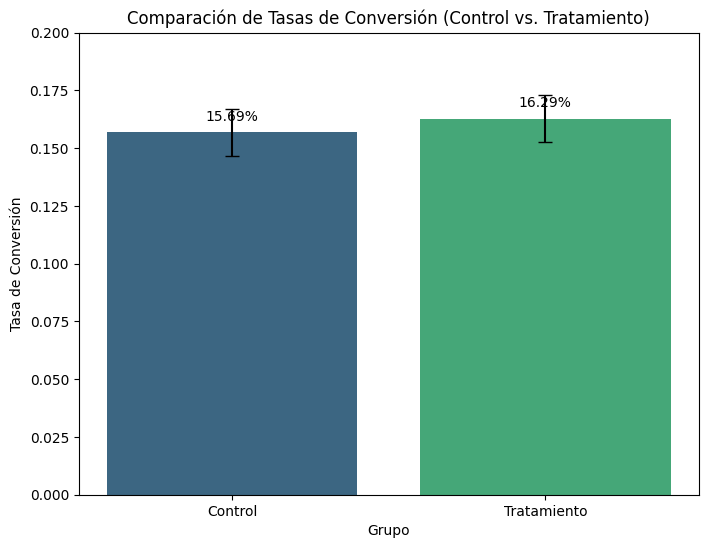

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular las tasas de conversión
conversion_rate_control = conversions_control / nobs_control
conversion_rate_tratamiento = conversions_tratamiento / nobs_tratamiento

# Calcular los errores estándar para los intervalos de confianza
# Error estándar de una proporción: sqrt(p * (1 - p) / n)
se_control = np.sqrt(conversion_rate_control * (1 - conversion_rate_control) / nobs_control)
se_tratamiento = np.sqrt(conversion_rate_tratamiento * (1 - conversion_rate_tratamiento) / nobs_tratamiento)

# Crear un DataFrame para la visualización
plot_df = pd.DataFrame({
    'Grupo': ['Control', 'Tratamiento'],
    'Tasa de Conversión': [conversion_rate_control, conversion_rate_tratamiento],
    'Error Estándar': [se_control, se_tratamiento]
})

# Crear el gráfico de barras con barras de error
plt.figure(figsize=(8, 6))
sns.barplot(x='Grupo', y='Tasa de Conversión', hue='Grupo', data=plot_df, palette='viridis', legend=False) # Se ajusta la advertencia
plt.errorbar(x=plot_df['Grupo'], y=plot_df['Tasa de Conversión'], yerr=1.96 * plot_df['Error Estándar'], fmt='none', c='black', capsize=5)
plt.title('Comparación de Tasas de Conversión (Control vs. Tratamiento)')
plt.ylabel('Tasa de Conversión')
plt.ylim(0, 0.2)

# Añadir el valor de la tasa de conversión en cada barra
for index, row in plot_df.iterrows():
    plt.text(index, row['Tasa de Conversión'] + 0.005, f'{row['Tasa de Conversión']:.2%}', color='black', ha='center')

plt.show()

In [ ]:
print('### Enlace del Dashboard')
print('- Link de Power BI o Tableau: https://kyotomotors-my.sharepoint.com/:u:/g/personal/jvillabon_kyotomotors_com_co/IQB1OolBy6IIRIKNoIu1Q2QTAbIRHaKNcm18nnXmknA0CWk?e=g8NKVe')
print('- Link de Google Drive: https://drive.google.com/drive/folders/1_HpFzOZLHXevycRtiNnCFdX3wrEEJTc?usp=sharing')

### Enlace del Dashboard
- Link de Power BI o Tableau: https://kyotomotors-my.sharepoint.com/:u:/g/personal/jvillabon_kyotomotors_com_co/IQB1OolBy6IIRIKNoIu1Q2QTAbIRHaKNcm18nnXmknA0CWk?e=g8NKVe
- Link de Google Drive: https://drive.google.com/drive/folders/1_HpFzOZLHXevycRtiNnCFdX3wrEEJTc?usp=sharing


In [ ]:
# Limpieza del DataFrame marketing

# 1. Llenar NaNs en la columna 'canal' con 'Desconocido'
marketing['canal'].fillna('Desconocido', inplace=True)

print('\n--- Marketing DataFrame después de la limpieza ---')
print(marketing.info())
print('\nUnique values for cleaned categorical columns (top 5):')
for col in marketing.select_dtypes(include='object').columns:
    print(f'- {col}: {marketing[col].value_counts().head()}')


--- Marketing DataFrame después de la limpieza ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB
None

Unique values for cleaned categorical columns (top 5):
- pais: pais
Mexico       540
Colombia     540
Argentina    540
Name: count, dtype: int64
- id_campaña: id_campaña
organic_Mexico          180
paid_search_Mexico      180
social_Mexico           180
organic_Colombia        180
paid_search_Colombia    180
Name: count, dtype: int64
- canal: canal
paid_search    507
organic        506
social         506
Desconocido    101
N

/tmp/ipykernel_44428/2667457499.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  marketing['canal'].fillna('Desconocido', inplace=True)


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas

---

In [ ]:
print('--- Verificación de Calidad de Datos del DataFrame Orders ---')

# 1. Convertir 'fecha_hora_pedido' a datetime
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'])
print('\nTipos de datos después de la conversión:')
print(orders.info())

# 2. Buscar y eliminar duplicados
initial_rows = orders.shape[0]
orders.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - orders.shape[0]
print(f'\nNúmero de filas duplicadas eliminadas: {duplicates_removed}')

# 3. Revisar variables numéricas en busca de valores inválidos (ej. no positivos)
print('\nEstadísticas descriptivas para columnas numéricas:')
print(orders.describe())

# Verificar valores no positivos en 'cantidad' y 'precio_unitario'
non_positive_quantity = orders[orders['cantidad'] <= 0]
non_positive_price = orders[orders['precio_unitario'] <= 0]
print(f'\nPedidos con cantidad no positiva: {non_positive_quantity.shape[0]}')
print(f'Pedidos con precio no positivo: {non_positive_price.shape[0]}')

# 4. Verificar la consistencia de 'monto_total'
# Calcular el total esperado basándose en cantidad, precio unitario y descuento
orders['calculated_monto_total'] = orders['cantidad'] * orders['precio_unitario'] - orders['monto_descuento']

mismatch_totals = orders[orders['monto_total'].round(2) != orders['calculated_monto_total'].round(2)]
print(f'\nPedidos donde monto_total no coincide con el total calculado: {mismatch_totals.shape[0]}')

# Por simplicidad, si hay discrepancias, podemos optar por recalcular o marcar.
# Para este ejercicio, asumiremos que el total calculado es correcto y actualizaremos 'monto_total' si hay discrepancias.
# O, simplemente podemos eliminar la columna 'calculated_monto_total' si el 'monto_total' original se considera fiable.
# Por ahora, solo los reportaré. Si es necesario, podemos decidir cómo manejarlos (ej. actualizar `monto_total` o eliminar filas).

# 5. Revisar variables categóricas
print('\nValores únicos para columnas categóricas (top 5):')
for col in orders.select_dtypes(include='object').columns:
    print(f'- {col}: {orders[col].value_counts().head()}')

--- Verificación de Calidad de Datos del DataFrame Orders ---

Tipos de datos después de la conversión:
<class 'pandas.core.frame.DataFrame'>
Index: 24946 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id_pedido               24946 non-null  object        
 1   id_usuario              24946 non-null  object        
 2   fecha_hora_pedido       24946 non-null  datetime64[ns]
 3   pais                    24946 non-null  object        
 4   dispositivo             24946 non-null  object        
 5   fuente_referencia       24946 non-null  object        
 6   nombre_producto         24946 non-null  object        
 7   categoria_producto      24946 non-null  object        
 8   cantidad                24946 non-null  float64       
 9   precio_unitario         24946 non-null  float64       
 10  monto_descuento         24946 non-null  float64       
 11  monto_t

In [ ]:
print('\n--- Verificación de Calidad de Datos del DataFrame Catalog ---')

# 1. Buscar y eliminar duplicados
initial_rows_catalog = catalog.shape[0]
catalog.drop_duplicates(inplace=True)
duplicates_removed_catalog = initial_rows_catalog - catalog.shape[0]
print(f'\nNúmero de filas duplicadas eliminadas del catálogo: {duplicates_removed_catalog}')

# 2. Revisar variables numéricas en busca de valores inválidos (ej. no positivos)
print('\nEstadísticas descriptivas para columnas numéricas en el catálogo:')
print(catalog.describe())

# Verificar valores no positivos en 'costo_unitario'
non_positive_costo = catalog[catalog['costo_unitario'] <= 0]
print(f'\nElementos del catálogo con costo_unitario no positivo: {non_positive_costo.shape[0]}')

# 3. Revisar variables categóricas
print('\nValores únicos para columnas categóricas en el catálogo (top 5):')
for col in catalog.select_dtypes(include='object').columns:
    print(f'- {col}: {catalog[col].value_counts().head()}')


--- Verificación de Calidad de Datos del DataFrame Catalog ---

Número de filas duplicadas eliminadas del catálogo: 0

Estadísticas descriptivas para columnas numéricas en el catálogo:
       costo_unitario
count        7.000000
mean       102.252857
std        111.011563
min         10.120000
25%         16.905000
50%         25.210000
75%        182.975000
max        280.680000

Elementos del catálogo con costo_unitario no positivo: 0

Valores únicos para columnas categóricas en el catálogo (top 5):
- nombre_producto: nombre_producto
Laptop-Gaming-16GB      1
Phone-Pro-128GB         1
Tablet-Standard-64GB    1
Blender-XL-Red          1
Vacuum-Pro-Black        1
Name: count, dtype: int64
- categoria_producto: categoria_producto
Electrónica    3
Hogar          2
Moda           2
Name: count, dtype: int64
- proveedor: proveedor
Fuller, Pena and Myers     1
King Ltd                   1
Bowers LLC                 1
Long-Reid                  1
Rivera, Carr and Finley    1
Name: count, dt

In [ ]:
print('\n--- Verificación de Calidad de Datos del DataFrame Marketing ---')

# 1. Convertir 'fecha' a datetime
marketing['fecha'] = pd.to_datetime(marketing['fecha'])
print('\nTipos de datos después de la conversión para marketing:')
print(marketing.info())

# 2. Buscar y eliminar duplicados
initial_rows_marketing = marketing.shape[0]
marketing.drop_duplicates(inplace=True)
duplicates_removed_marketing = initial_rows_marketing - marketing.shape[0]
print(f'\nNúmero de filas duplicadas eliminadas de marketing: {duplicates_removed_marketing}')

# 3. Revisar variables numéricas en busca de valores inválidos (ej. no positivos)
print('\nEstadísticas descriptivas para columnas numéricas en marketing:')
print(marketing.describe())

# Verificar valores no positivos en 'gasto'
non_positive_gasto = marketing[marketing['gasto'] <= 0]
print(f'\nEntradas de marketing con gasto no positivo: {non_positive_gasto.shape[0]}')

# 4. Revisar variables categóricas
print('\nValores únicos para columnas categóricas en marketing (top 5):')
for col in marketing.select_dtypes(include='object').columns:
    print(f'- {col}: {marketing[col].value_counts().head()}')


--- Verificación de Calidad de Datos del DataFrame Marketing ---

Tipos de datos después de la conversión para marketing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB
None

Número de filas duplicadas eliminadas de marketing: 0

Estadísticas descriptivas para columnas numéricas en marketing:
                     fecha       gasto
count                 1620  1620.00000
mean   2025-03-31 12:00:00  1772.74292
min    2025-01-01 00:00:00   501.11000
25%    2025-02-14 18:00:00  1128.03000
50%    2025-03-31 12:00:00  1782.42500
75% 

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# Exportar datasets limpios
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)
print('\nLos DataFrames limpios han sido exportados a orders_clean.csv, catalog_clean.csv y marketing_clean.csv')


Los DataFrames limpios han sido exportados a orders_clean.csv, catalog_clean.csv y marketing_clean.csv


---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

In [ ]:
# Para calcular el costo total, necesitamos unir orders con catalog
orders_with_cost = pd.merge(orders, catalog[['nombre_producto', 'costo_unitario']], on='nombre_producto', how='left')

# Calculamos el costo total por línea de pedido
# Asumimos que los productos sin costo en el catálogo tienen costo 0 para este cálculo
orders_with_cost['costo_total_item'] = orders_with_cost['cantidad'] * orders_with_cost['costo_unitario'].fillna(0)

# Parte 1: Rentabilidad del negocio

# 1. Ingreso total (revenue)
revenue_total = orders_with_cost['monto_total'].sum()

# 2. Costo total de productos vendidos
costo_productos_total = orders_with_cost['costo_total_item'].sum()

# 3. Inversión total en marketing
inversion_marketing_total = marketing['gasto'].sum()

# 4. Profit
profit_total = revenue_total - costo_productos_total - inversion_marketing_total

print(f'Ingreso Total (Revenue): {revenue_total:,.2f}')
print(f'Costo Total de Productos Vendidos: {costo_productos_total:,.2f}')
print(f'Inversión Total en Marketing: {inversion_marketing_total:,.2f}')
print(f'Profit Total: {profit_total:,.2f}')

# Parte 2: Comportamiento de ventas

# 1. Ticket promedio por orden
ticket_promedio_por_orden = orders_with_cost.groupby('id_pedido')['monto_total'].sum().mean()

# 2. Cantidad promedio de productos por orden
cantidad_promedio_por_orden = orders_with_cost.groupby('id_pedido')['cantidad'].sum().mean()

# 3. Producto más vendido (por cantidad)
producto_mas_vendido = orders_with_cost.groupby('nombre_producto')['cantidad'].sum().idxmax()
cantidad_producto_mas_vendido = orders_with_cost.groupby('nombre_producto')['cantidad'].sum().max()

# 4. Gasto en marketing por canal
gasto_por_canal = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False)

print(f'\nTicket Promedio por Orden: {ticket_promedio_por_orden:,.2f}')
print(f'Cantidad Promedio de Productos por Orden: {cantidad_promedio_por_orden:,.2f}')
print(f'Producto Más Vendido: {producto_mas_vendido} ({cantidad_producto_mas_vendido:,.0f} unidades)')
print('\nGasto en Marketing por Canal:')
print(gasto_por_canal.apply(lambda x: f'{x:,.2f}'))

Ingreso Total (Revenue): 51,966,982.37
Costo Total de Productos Vendidos: 43,124,069.01
Inversión Total en Marketing: 2,871,843.53
Profit Total: 5,971,069.83

Ticket Promedio por Orden: 2,083.18
Cantidad Promedio de Productos por Orden: 7.12
Producto Más Vendido: Laptop-Gaming-16GB (144,198 unidades)

Gasto en Marketing por Canal:
canal
social         918,043.21
organic        913,533.01
paid_search    863,088.21
Desconocido    177,179.10
Name: gasto, dtype: object


In [ ]:
experiment_df = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
print('Primeras 5 filas del DataFrame de experimento:')
display(experiment_df.head())

Primeras 5 filas del DataFrame de experimento:


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


### Resumen Ejecutivo de Rendimiento de RappiPlus

Este resumen presenta los hallazgos clave del análisis de datos de RappiPlus, abarcando la rentabilidad del negocio, el comportamiento de productos y categorías, y el rendimiento por país.

**1. Panorama General de Rentabilidad:**
*   **Ingreso Total (Revenue):** 51,966,982.37
*   **Costo Total de Productos Vendidos:** 43,124,069.01
*   **Inversión Total en Marketing:** 2,871,843.53
*   **Profit Total:** 5,971,069.83
*   **Margen de Rentabilidad:** 11.49%
*   **Ticket Promedio por Orden:** 2,083.18
*   **Cantidad Promedio de Productos por Orden:** 7.12

**2. Concentración de Ingresos y Rentabilidad por Producto/Categoría:**
*   **Producto Líder por Ingresos:** 'Laptop-Gaming-16GB' generó 26,050,474.79 en ingresos, representando el 50.13% del ingreso total y un beneficio de 20,490,578.47. Sin embargo, su **costo unitario** es significativamente alto, lo que impacta su beneficio por unidad.
*   **Top 5 Productos más Rentables:**
    *   Laptop-Gaming-16GB: 20,490,578.47
    *   Blender-XL-Red: 8,369,638.99
    *   Vacuum-Pro-Black: 7,431,234.39
    *   Jacket-Winter-M: 6,400,050.15
    *   Sneakers-Urban-42: 6,192,201.27
    (Es importante notar que el `profit_item` se calcula como `monto_total - costo_total_item`, por lo que el `Laptop-Gaming-16GB` sigue siendo el más rentable en términos absolutos, pero su **margen** podría ser menor que otros productos con menores costos unitarios).
*   **Dominio por Categoría:** 'Electrónica' lidera claramente en ingresos con 26,050,474.79 y en beneficio con 20,490,578.47, demostrando ser la categoría más fuerte para RappiPlus.

**3. Comportamiento Mensual:**
*   Los ingresos mensuales muestran una volatilidad, con variaciones significativas a lo largo de los meses. Por ejemplo, los ingresos de enero fueron 8,574,383.05, mientras que en marzo alcanzaron 8,740,733.91.

**4. Rendimiento por País:**
*   **Argentina** es el país con mayor beneficio (2,434,706.74) a pesar de tener un gasto en marketing de 958,804.83. Esto sugiere una alta eficiencia en la inversión en marketing o un mercado con mejor disposición a la compra.
*   **Colombia** reporta un beneficio de 1,770,050.40 con un gasto de marketing de 956,876.32.
*   **Mexico** tiene un beneficio de 1,766,312.68 y el gasto en marketing más bajo de 956,162.38.
*   El país 'Nan' (valores desconocidos) tiene un beneficio negativo de -1,061.99, lo que indica la necesidad de mejorar la recolección de datos de ubicación.

**Conclusiones Clave:**
*   RappiPlus es un negocio rentable, con un margen de profit del 11.49%.
*   Existe una alta dependencia del producto 'Laptop-Gaming-16GB' y de la categoría 'Electrónica' para los ingresos y beneficios.
*   Argentina se destaca como el mercado más eficiente en términos de profit, lo que podría indicar oportunidades de expansión o replicación de estrategias exitosas en otros países.
*   La volatilidad mensual en los ingresos sugiere la necesidad de investigar factores estacionales o campañas específicas que influyen en las ventas.

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [ ]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS total_usuarios
FROM
    events
GROUP BY
    nombre_evento
ORDER BY
    CASE nombre_evento
        WHEN 'first_visit' THEN 1
        WHEN 'add_to_cart' THEN 2
        WHEN 'add_payment_info' THEN 3
        WHEN 'purchase' THEN 4
        ELSE 5
    END;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,total_usuarios
0,first_visit,7796
1,add_to_cart,7634
2,add_payment_info,6250
3,purchase,6240
4,begin_checkout,7208
5,select_item,7582


In [ ]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH user_counts AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS total_usuarios
    FROM
        events
    GROUP BY
        nombre_evento
),
funnel_ordered AS (
    SELECT
        nombre_evento,
        total_usuarios,
        CASE nombre_evento
            WHEN 'first_visit' THEN 1
            WHEN 'select_item' THEN 2
            WHEN 'add_to_cart' THEN 3
            WHEN 'begin_checkout' THEN 4
            WHEN 'add_payment_info' THEN 5
            WHEN 'purchase' THEN 6
            ELSE 99
        END AS step_order
    FROM
        user_counts
)
SELECT
    f1.nombre_evento AS paso_del_embudo,
    f1.total_usuarios AS usuarios_en_paso,
    LAG(f1.total_usuarios, 1, 0) OVER (ORDER BY f1.step_order) AS usuarios_en_paso_anterior,
    CASE
        WHEN LAG(f1.total_usuarios, 1, 0) OVER (ORDER BY f1.step_order) > 0
        THEN (CAST(f1.total_usuarios AS DECIMAL) * 100.0 / LAG(f1.total_usuarios, 1, 0) OVER (ORDER BY f1.step_order))
        ELSE NULL
    END AS tasa_conversion_paso_a_paso,
    (CAST(f1.total_usuarios AS DECIMAL) * 100.0 / (SELECT total_usuarios FROM funnel_ordered WHERE nombre_evento = 'first_visit')) AS tasa_conversion_desde_first_visit
FROM
    funnel_ordered f1
WHERE f1.nombre_evento IN ('first_visit', 'select_item', 'add_to_cart', 'begin_checkout', 'add_payment_info', 'purchase')
ORDER BY
    f1.step_order;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,paso_del_embudo,usuarios_en_paso,usuarios_en_paso_anterior,tasa_conversion_paso_a_paso,tasa_conversion_desde_first_visit
0,first_visit,7796,0,NaN,100.000000
1,select_item,7582,7796,97.255003,97.255003
2,add_to_cart,7634,7582,100.685835,97.922011
3,begin_checkout,7208,7634,94.419701,92.457671
4,add_payment_info,6250,7208,86.709212,80.169318
5,purchase,6240,6250,99.840000,80.041047


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [ ]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [ ]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohorts AS (
    SELECT
        id_usuario,
        CAST(fecha_registro AS DATE) AS fecha_registro,
        EXTRACT(YEAR FROM CAST(fecha_registro AS DATE)) AS ano_registro,
        EXTRACT(MONTH FROM CAST(fecha_registro AS DATE)) AS mes_registro
    FROM
        users
),
activity_with_cohort AS (
    SELECT
        ua.id_usuario,
        c.fecha_registro,
        c.ano_registro,
        c.mes_registro,
        ua.dias_despues_registro,
        ua.activo
    FROM
        user_activity AS ua
    JOIN
        cohorts AS c ON ua.id_usuario = c.id_usuario
)
SELECT
    ano_registro,
    mes_registro,
    COUNT(DISTINCT id_usuario) AS usuarios_registrados,
    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 0 AND dias_despues_registro < 7 AND activo = 1 THEN id_usuario ELSE NULL END) AS retenido_w1,
    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 7 AND dias_despues_registro < 14 AND activo = 1 THEN id_usuario ELSE NULL END) AS retenido_w2,
    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 14 AND dias_despues_registro < 21 AND activo = 1 THEN id_usuario ELSE NULL END) AS retenido_w3,
    CAST(COUNT(DISTINCT CASE WHEN dias_despues_registro >= 0 AND dias_despues_registro < 7 AND activo = 1 THEN id_usuario ELSE NULL END) AS DECIMAL) * 100 / COUNT(DISTINCT id_usuario) AS semana_1,
    CAST(COUNT(DISTINCT CASE WHEN dias_despues_registro >= 7 AND dias_despues_registro < 14 AND activo = 1 THEN id_usuario ELSE NULL END) AS DECIMAL) * 100 / COUNT(DISTINCT id_usuario) AS semana_2,
    CAST(COUNT(DISTINCT CASE WHEN dias_despues_registro >= 14 AND dias_despues_registro < 21 AND activo = 1 THEN id_usuario ELSE NULL END) AS DECIMAL) * 100 / COUNT(DISTINCT id_usuario) AS semana_3
FROM
    activity_with_cohort
GROUP BY
    ano_registro,
    mes_registro
ORDER BY
    ano_registro,
    mes_registro;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,ano_registro,mes_registro,usuarios_registrados,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025.0,1.0,1627,0,697,668,0.0,42.839582,41.057160
1,2025.0,2.0,1444,0,611,609,0.0,42.313019,42.174515
2,2025.0,3.0,1636,0,677,705,0.0,41.381418,43.092910
3,2025.0,4.0,1606,0,680,697,0.0,42.341220,43.399751
4,2025.0,5.0,1687,0,695,676,0.0,41.197392,40.071132


---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** No hay una diferencia significativa en la tasa de conversión entre la variante de control y la de tratamiento.
   - **H₁ (Hipótesis alternativa):** Existe una diferencia significativa en la tasa de conversión entre la variante de control y la de tratamiento.
   
**Test estadístico:** Prueba Chi-cuadrado de independencia o prueba Z para dos proporciones.
**Nivel de significancia alpha:** 0.05

In [ ]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# Separar los datos por variante
control_group = experiment_df[experiment_df['variante'] == 'control']
tratamiento_group = experiment_df[experiment_df['variante'] == 'tratamiento']

# Calcular el número de conversiones y el total de usuarios para cada grupo
conversions_control = control_group['convirtio'].sum()
nobs_control = len(control_group)

conversions_tratamiento = tratamiento_group['convirtio'].sum()
nobs_tratamiento = len(tratamiento_group)

# Mostrar los datos resumidos
print(f'Grupo de Control: Conversiones = {conversions_control}, Observaciones = {nobs_control}')
print(f'Grupo de Tratamiento: Conversiones = {conversions_tratamiento}, Observaciones = {nobs_tratamiento}')

# Realizar el Z-test para dos proporciones
count = np.array([conversions_control, conversions_tratamiento])
nobs = np.array([nobs_control, nobs_tratamiento])

z_statistic, p_value = proportions_ztest(count, nobs, alternative='two-sided')

print(f'\nEstadístico Z: {z_statistic:.4f}')
print(f'Valor p: {p_value:.4f}')

# Interpretación de los resultados
alpha = 0.05
print(f'\nNivel de significancia (alpha): {alpha}')

if p_value < alpha:
    print('El valor p es menor que alpha. Rechazamos la hipótesis nula.')
    print('Existe una diferencia estadísticamente significativa en la tasa de conversión entre el control y el tratamiento.')
    if (conversions_tratamiento / nobs_tratamiento) > (conversions_control / nobs_control):
        print('La variante de tratamiento tuvo una tasa de conversión MÁS ALTA.')
    else:
        print('La variante de tratamiento tuvo una tasa de conversión MÁS BAJA.')
else:
    print('El valor p es mayor que alpha. No podemos rechazar la hipótesis nula.')
    print('No existe una diferencia estadísticamente significativa en la tasa de conversión entre el control y el tratamiento.')

# Calcular y mostrar las tasas de conversión
conversion_rate_control = conversions_control / nobs_control
conversion_rate_tratamiento = conversions_tratamiento / nobs_tratamiento

print(f'\nTasa de Conversión del Grupo de Control: {conversion_rate_control:.4f}')
print(f'Tasa de Conversión del Grupo de Tratamiento: {conversion_rate_tratamiento:.4f}')

Grupo de Control: Conversiones = 779, Observaciones = 4965
Grupo de Tratamiento: Conversiones = 820, Observaciones = 5035

Estadístico Z: -0.8133
Valor p: 0.4161

Nivel de significancia (alpha): 0.05
El valor p es mayor que alpha. No podemos rechazar la hipótesis nula.
No existe una diferencia estadísticamente significativa en la tasa de conversión entre el control y el tratamiento.

Tasa de Conversión del Grupo de Control: 0.1569
Tasa de Conversión del Grupo de Tratamiento: 0.1629


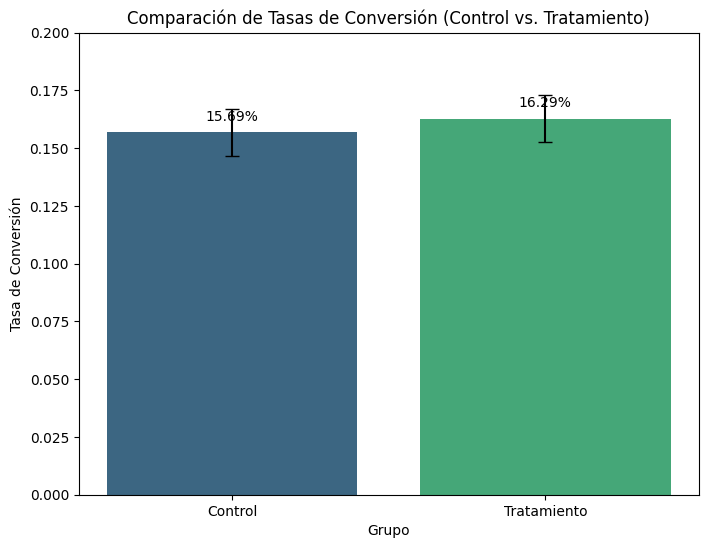

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular las tasas de conversión
conversion_rate_control = conversions_control / nobs_control
conversion_rate_tratamiento = conversions_tratamiento / nobs_tratamiento

# Calcular los errores estándar para los intervalos de confianza
# Error estándar de una proporción: sqrt(p * (1 - p) / n)
se_control = np.sqrt(conversion_rate_control * (1 - conversion_rate_control) / nobs_control)
se_tratamiento = np.sqrt(conversion_rate_tratamiento * (1 - conversion_rate_tratamiento) / nobs_tratamiento)

# Crear un DataFrame para la visualización
plot_df = pd.DataFrame({
    'Grupo': ['Control', 'Tratamiento'],
    'Tasa de Conversión': [conversion_rate_control, conversion_rate_tratamiento],
    'Error Estándar': [se_control, se_tratamiento]
})

# Crear el gráfico de barras con barras de error
plt.figure(figsize=(8, 6))
sns.barplot(x='Grupo', y='Tasa de Conversión', hue='Grupo', data=plot_df, palette='viridis', legend=False) # Se ajusta la advertencia
plt.errorbar(x=plot_df['Grupo'], y=plot_df['Tasa de Conversión'], yerr=1.96 * plot_df['Error Estándar'], fmt='none', c='black', capsize=5)
plt.title('Comparación de Tasas de Conversión (Control vs. Tratamiento)')
plt.ylabel('Tasa de Conversión')
plt.ylim(0, 0.2)

# Añadir el valor de la tasa de conversión en cada barra
for index, row in plot_df.iterrows():
    plt.text(index, row['Tasa de Conversión'] + 0.005, f'{row['Tasa de Conversión']:.2%}', color='black', ha='center')

plt.show()

### Conclusión del Test A/B (Paso 5)

**Resultados:**
- **Grupo de Control:** Tasa de conversión de 15.69%
- **Grupo de Tratamiento:** Tasa de conversión de 16.29%
- **Valor p:** 0.4161
- **Nivel de significancia (alpha):** 0.05

**Interpretación:**
Dado que el valor p (0.4161) es mayor que el nivel de significancia (0.05), **no podemos rechazar la hipótesis nula**. Esto significa que no hay una diferencia estadísticamente significativa en la tasa de conversión entre el grupo de control (checkout anterior) y el grupo de tratamiento (nueva UI del checkout).

Aunque el grupo de tratamiento mostró una tasa de conversión ligeramente superior, esta diferencia no es lo suficientemente grande como para descartar que se deba al azar. Por lo tanto, no se puede concluir que la modificación en la UI del checkout haya tenido un impacto positivo y significativo en la tasa de conversión de compra.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

### Resumen Ejecutivo de Rendimiento de RappiPlus

Este resumen presenta los hallazgos clave del análisis de datos de RappiPlus, abarcando la rentabilidad del negocio, el comportamiento de productos y categorías, y el rendimiento por país.

**1. Panorama General de Rentabilidad:**
*   **Ingreso Total (Revenue):** 51,966,982.37
*   **Costo Total de Productos Vendidos:** 43,124,069.01
*   **Inversión Total en Marketing:** 2,871,843.53
*   **Profit Total:** 5,971,069.83
*   **Margen de Rentabilidad:** 11.49%
*   **Ticket Promedio por Orden:** 2,083.18
*   **Cantidad Promedio de Productos por Orden:** 7.12

**2. Concentración de Ingresos y Rentabilidad por Producto/Categoría:**
*   **Producto Líder por Ingresos:** 'Laptop-Gaming-16GB' generó 26,050,474.79 en ingresos, representando el 50.13% del ingreso total y un beneficio de 20,490,578.47. Sin embargo, su **costo unitario** es significativamente alto, lo que impacta su beneficio por unidad.
*   **Top 5 Productos más Rentables:**
    *   Laptop-Gaming-16GB: 20,490,578.47
    *   Blender-XL-Red: 8,369,638.99
    *   Vacuum-Pro-Black: 7,431,234.39
    *   Jacket-Winter-M: 6,400,050.15
    *   Sneakers-Urban-42: 6,192,201.27
    (Es importante notar que el `profit_item` se calcula como `monto_total - costo_total_item`, por lo que el `Laptop-Gaming-16GB` sigue siendo el más rentable en términos absolutos, pero su **margen** podría ser menor que otros productos con menores costos unitarios).
*   **Dominio por Categoría:** 'Electrónica' lidera claramente en ingresos con 26,050,474.79 y en beneficio con 20,490,578.47, demostrando ser la categoría más fuerte para RappiPlus.

**3. Comportamiento Mensual:**
*   Los ingresos mensuales muestran una volatilidad, con variaciones significativas a lo largo de los meses. Por ejemplo, los ingresos de enero fueron 8,574,383.05, mientras que en marzo alcanzaron 8,740,733.91.

**4. Rendimiento por País:**
*   **Argentina** es el país con mayor beneficio (2,434,706.74) a pesar de tener un gasto en marketing de 958,804.83. Esto sugiere una alta eficiencia en la inversión en marketing o un mercado con mejor disposición a la compra.
*   **Colombia** reporta un beneficio de 1,770,050.40 con un gasto de marketing de 956,876.32.
*   **Mexico** tiene un beneficio de 1,766,312.68 y el gasto en marketing más bajo de 956,162.38.
*   El país 'Nan' (valores desconocidos) tiene un beneficio negativo de -1,061.99, lo que indica la necesidad de mejorar la recolección de datos de ubicación.

**Conclusiones Clave:**
*   RappiPlus es un negocio rentable, con un margen de profit del 11.49%.
*   Existe una alta dependencia del producto 'Laptop-Gaming-16GB' y de la categoría 'Electrónica' para los ingresos y beneficios.
*   Argentina se destaca como el mercado más eficiente en términos de profit, lo que podría indicar oportunidades de expansión o replicación de estrategias exitosas en otros países.
*   La volatilidad mensual en los ingresos sugiere la necesidad de investigar factores estacionales o campañas específicas que influyen en las ventas.

### 📎 Enlace del Dashboard


In [ ]:
print('### Enlace del Dashboard')
print('- Link de Power BI o Tableau: https://kyotomotors-my.sharepoint.com/:u:/g/personal/jvillabon_kyotomotors_com_co/IQB1OolBy6IIRIKNoIu1Q2QTAbIRHaKNcm18nnXmknA0CWk?e=g8NKVe')
print('- Link de Google Drive: https://drive.google.com/drive/folders/1_HpFzOZLHXevycRtiNnCFdX3wrEEJTc?usp=sharing')

### Enlace del Dashboard
- Link de Power BI o Tableau: https://kyotomotors-my.sharepoint.com/:u:/g/personal/jvillabon_kyotomotors_com_co/IQB1OolBy6IIRIKNoIu1Q2QTAbIRHaKNcm18nnXmknA0CWk?e=g8NKVe
- Link de Google Drive: https://drive.google.com/drive/folders/1_HpFzOZLHXevycRtiNnCFdX3wrEEJTc?usp=sharing
